# Hands-On Pertemuan 12 and 13: Data Cleaning, Preparation, and Visualization

## Objectives:
- **Pertemuan 12**: Master data cleaning and preparation techniques using Pandas.
- **Pertemuan 13**: Develop skills in data visualization using Matplotlib and Seaborn for effective data analysis.


## Pertemuan 12: Data Cleaning and Preparation using Pandas

### Topics Covered
- Identifying and handling missing data.
- Data transformation and normalization.
- Data filtering and deduplication.
- Standardization of categorical data.
- Outlier detection and handling.


In [11]:
# Exercise 1: Identifying and Handling Missing Data
import pandas as pd

# Sample dataset with missing values
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', None],
    'Age': [24, 30, None, 22, 35],
    'Salary': [48000, None, 57000, None, 60000]
}
df = pd.DataFrame(data)

# Filling missing values and dropping rows
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Salary'].fillna(df['Salary'].median(), inplace=True)
df.dropna(subset=['Name'], inplace=True)
print('After cleaning:\n', df)


After cleaning:
       Name    Age   Salary
0    Alice  24.00  48000.0
1      Bob  30.00  57000.0
2  Charlie  27.75  57000.0
3    David  22.00  57000.0


C:\Users\AKBAR\AppData\Local\Temp\ipykernel_3336\2224635855.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\AKBAR\AppData\Local\Temp\ipykernel_3336\2224635855.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [12]:
# Exercise 2: Standardizing Categorical Data
# Sample dataset with inconsistent categorical values
data = {
    'Product': ['Laptop', 'Laptop', 'Desktop', 'Tablet', 'Tablet'],
    'Category': ['Electronics', 'electronics', 'Electronics', 'Gadgets', 'gadgets']
}
df = pd.DataFrame(data)

# Standardize category values
df['Category'] = df['Category'].str.capitalize()
print('Standardized Data:\n', df)


Standardized Data:
    Product     Category
0   Laptop  Electronics
1   Laptop  Electronics
2  Desktop  Electronics
3   Tablet      Gadgets
4   Tablet      Gadgets


### Practice Tasks
- Load a dataset of your choice and identify missing values.
- Implement data transformations to normalize numerical columns.
- Standardize categorical columns and remove duplicates.


In [20]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', None],
    'Age': [24, 30, None, 22, 35],
    'Salary': [48000, None, 57000, None, 60000]
}

df = pd.DataFrame(data)

# 1. Mengidentifikasi Missing Values
missing_values = df.isnull().sum()

# 2. Normalisasi kolom numerik
numerical_columns = ['Age', 'Salary']
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# 3. Standarisasi Kolom Kategorikal 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_names = encoder.fit_transform(df[['Name']])
encoded_columns = encoder.get_feature_names_out(['Name'])

# Membuat dataframe untuk encoded data
encoded_df = pd.DataFrame(encoded_names, columns=encoded_columns, index=df.index)
df = pd.concat([df.drop(columns=['Name']), encoded_df], axis=1)

# Menghapus duplikasi data
df_cleaned = df.drop_duplicates()

missing_values, df_cleaned


(Name      1
 Age       1
 Salary    2
 dtype: int64,
         Age  Salary  Name_Alice  Name_Bob  Name_Charlie  Name_David  Name_None
 0  0.153846    0.00         1.0       0.0           0.0         0.0        0.0
 1  0.615385     NaN         0.0       1.0           0.0         0.0        0.0
 2       NaN    0.75         0.0       0.0           1.0         0.0        0.0
 3  0.000000     NaN         0.0       0.0           0.0         1.0        0.0
 4  1.000000    1.00         0.0       0.0           0.0         0.0        1.0)

## Pertemuan 13: Data Visualization using Matplotlib and Seaborn

### Topics Covered
- Plotting data distributions and comparisons.
- Creating time series visualizations.
- Visualizing relationships between variables.
- Customizing plot styles and layouts.


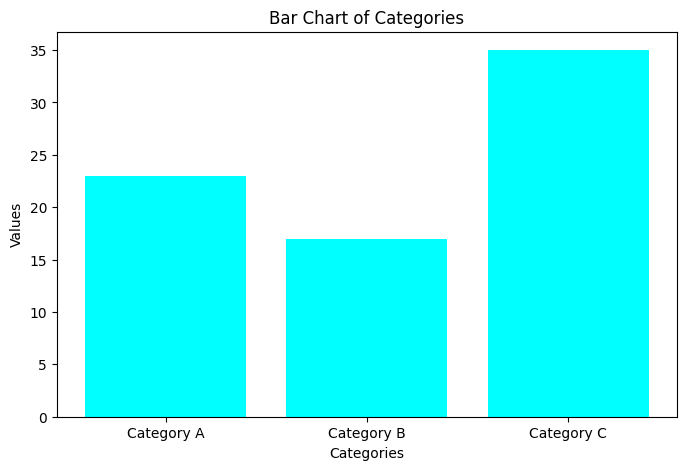

In [13]:
# Exercise 1: Basic Plotting with Matplotlib
import matplotlib.pyplot as plt

# Data for plotting
categories = ['Category A', 'Category B', 'Category C']
values = [23, 17, 35]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(categories, values, color='cyan')
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Chart of Categories')
plt.show()


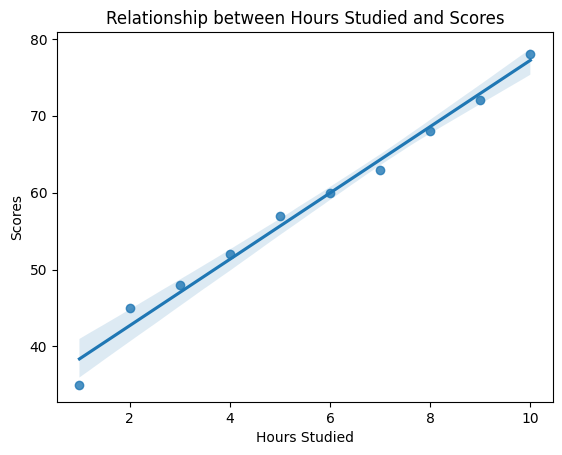

In [14]:
# Exercise 2: Seaborn for Relationship Visualization
import seaborn as sns
import pandas as pd

# Sample data
data = {
    'Hours Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Scores': [35, 45, 48, 52, 57, 60, 63, 68, 72, 78]
}
df = pd.DataFrame(data)

# Plot
sns.regplot(x='Hours Studied', y='Scores', data=df)
plt.title('Relationship between Hours Studied and Scores')
plt.show()


### Practice Tasks
- Use Matplotlib to create a multi-bar chart to compare data across groups.
- Generate scatter plots with Seaborn to explore relationships between variables in a dataset.
- Customize plot layouts and color schemes.


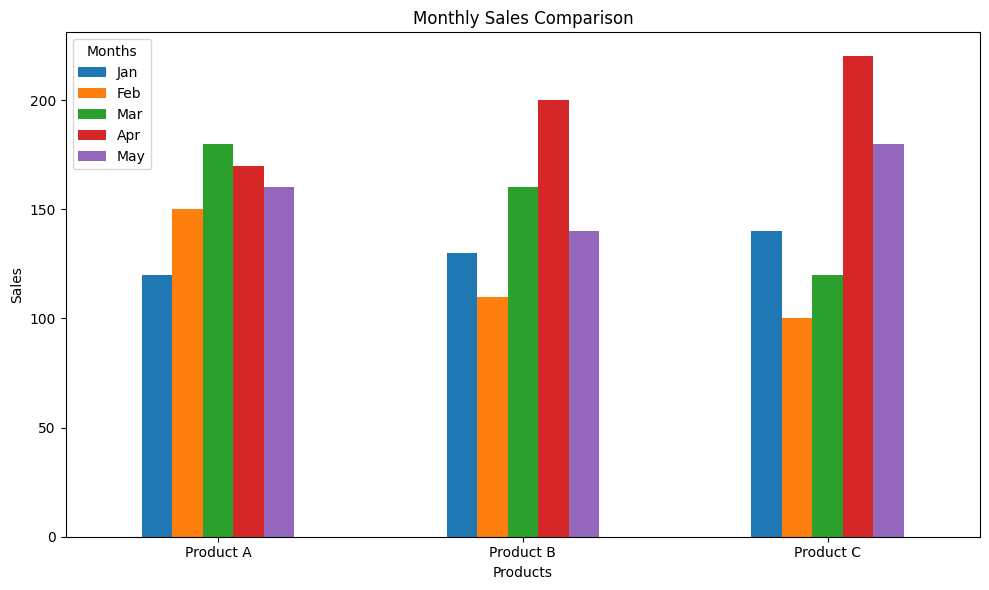

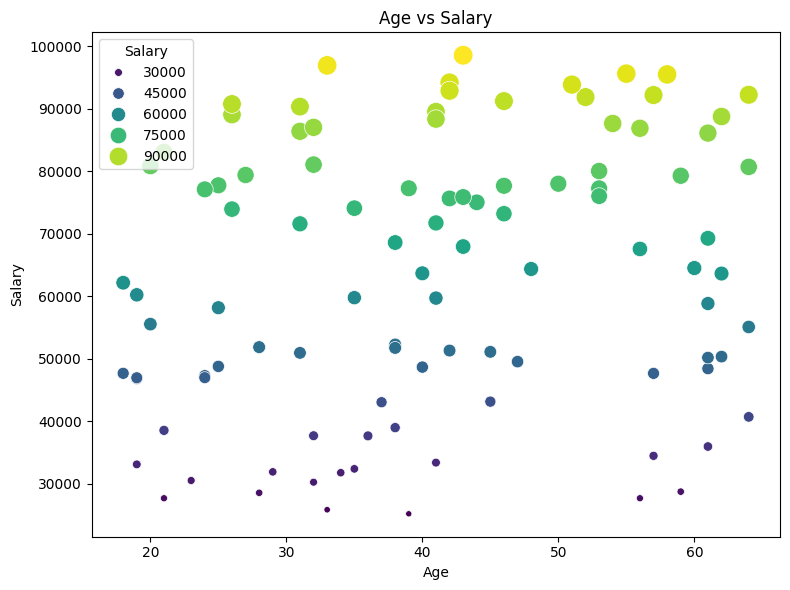

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Example Data for Multi-Bar Chart
categories = ['Product A', 'Product B', 'Product C']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
data = {
    'Jan': [120, 130, 140],
    'Feb': [150, 110, 100],
    'Mar': [180, 160, 120],
    'Apr': [170, 200, 220],
    'May': [160, 140, 180],
}
df = pd.DataFrame(data, index=categories)

# Create a Multi-Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
df.plot(kind='bar', ax=ax)
ax.set_title('Monthly Sales Comparison')
ax.set_ylabel('Sales')
ax.set_xlabel('Products')
plt.xticks(rotation=0)
plt.legend(title='Months', loc='upper left')
plt.tight_layout()

# Scatter Plot with Seaborn (Example Data)
# Generating a random dataset for demonstration
np.random.seed(42)
data = {
    'Age': np.random.randint(18, 65, size=100),
    'Salary': np.random.randint(25000, 100000, size=100)
}
df_seaborn = pd.DataFrame(data)

# Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Salary', data=df_seaborn, hue='Salary', palette='viridis', size='Salary', sizes=(20, 200))
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.tight_layout()

# Displaying the plots
plt.show()


## Homework for Students
- **Pertemuan 12**: Clean a real-world dataset (from Kaggle or another source), perform normalization, handle outliers, and prepare the data for analysis.
- **Pertemuan 13**: Create a dashboard with multiple visualizations to summarize a dataset of your choice.


**Pertemuan 12**

In [1]:
import pandas as pd
df = pd.read_csv('C:\\Users\\AKBAR\\Downloads\\titanic.csv')
num_rows = len(df)
print(f"Jumlah baris dataset: {num_rows}")

Jumlah baris dataset: 891


In [4]:
import pandas as pd

dataset = pd.read_csv('C:\\Users\\AKBAR\\Downloads\\titanic.csv')
# Mengecek nilai kosong di setiap kolom
missing_values = dataset.isnull().sum()
print(missing_values[missing_values > 0])


Age         177
Cabin       687
Embarked      2
dtype: int64


In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def bersihkan_data(dataset):
    # Menghapus baris dengan nilai kosong
    dataset = dataset.dropna()
    
    # Mendapatkan kolom numerik
    numerik_cols = dataset.select_dtypes(include=['number']).columns
    
    # Menghapus outlier menggunakan IQR
    Q1 = dataset[numerik_cols].quantile(0.25)
    Q3 = dataset[numerik_cols].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    for col in numerik_cols:
        dataset = dataset[(dataset[col] >= batas_bawah[col]) & (dataset[col] <= batas_atas[col])]
    
    # Normalisasi kolom numerik menggunakan MinMaxScaler
    scaler = MinMaxScaler()
    dataset[numerik_cols] = scaler.fit_transform(dataset[numerik_cols])
    
    return dataset

# Membaca data dari file CSV
data = pd.read_csv("C:\\Users\\AKBAR\\Downloads\\titanic.csv")

# Membersihkan data
data_bersih = bersihkan_data(data)

# Menampilkan hasil
print(data_bersih.head())


    PassengerId  Survived  Pclass  \
1      0.000000       1.0     0.0   
3      0.002252       1.0     0.0   
6      0.005631       0.0     0.0   
11     0.011261       1.0     0.0   
23     0.024775       1.0     0.0   

                                                 Name     Sex       Age  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  0.468892   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  0.430956   
6                             McCarthy, Mr. Timothy J    male  0.671219   
11                           Bonnell, Miss. Elizabeth  female  0.721801   
23                       Sloper, Mr. William Thompson    male  0.342438   

    SibSp  Parch    Ticket      Fare Cabin Embarked  
1     0.5    0.0  PC 17599  0.432369   C85        C  
3     0.5    0.0    113803  0.322078  C123        S  
6     0.0    0.0     17463  0.314572   E46        S  
11    0.0    0.0    113783  0.161039  C103        S  
23    0.0    0.0    113788  0.215325    A6        S  


In [6]:
print(dataset.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Pertemuan 13**

In [9]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


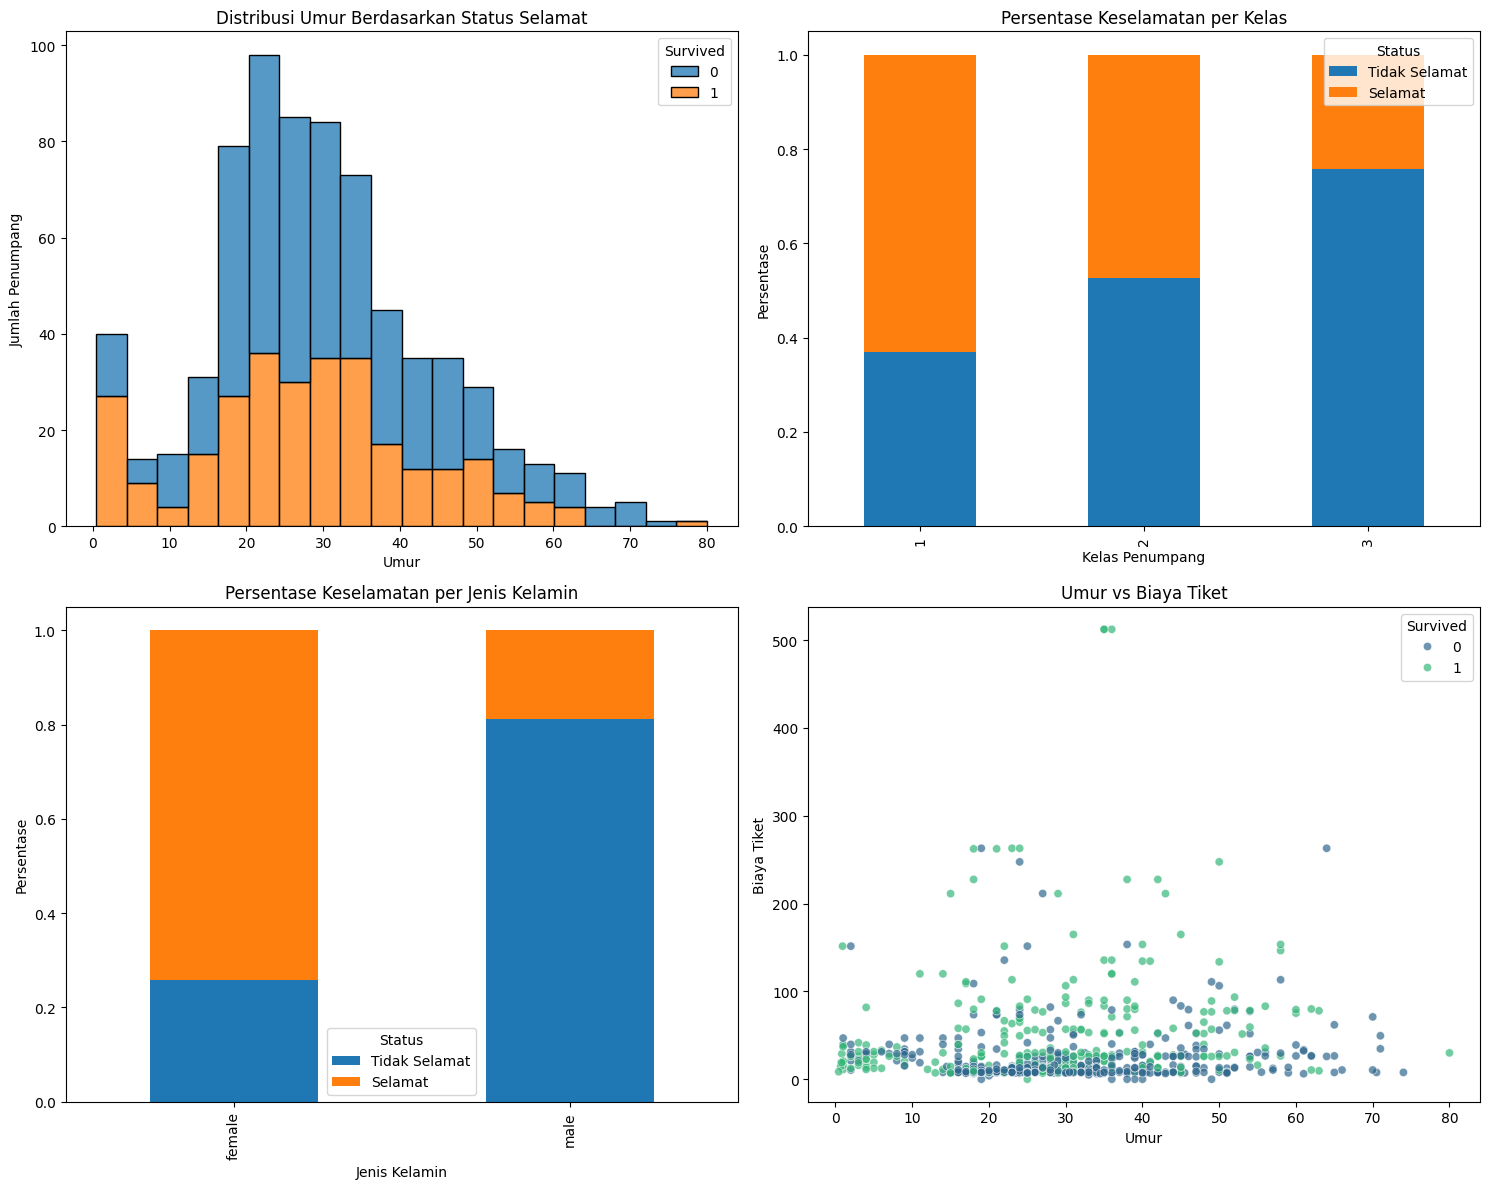


Statistik Ringkasan Keselamatan:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Keselamatan Berdasarkan Kelas:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Keselamatan Berdasarkan Jenis Kelamin:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def buat_visualisasi_titanic(data):
    plt.figure(figsize=(15, 12))
    
    # 1. Histogram Umur Penumpang berdasarkan Status Selamat
    plt.subplot(2, 2, 1)
    sns.histplot(data=data, x='Age', hue='Survived', multiple='stack', bins=20)
    plt.title("Distribusi Umur Berdasarkan Status Selamat")
    plt.xlabel("Umur")
    plt.ylabel("Jumlah Penumpang")
    
    # 2. Perbandingan Kelas dengan Status Selamat
    plt.subplot(2, 2, 2)
    survival_by_class = data.groupby('Pclass')['Survived'].value_counts(normalize=True).unstack()
    survival_by_class.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title("Persentase Keselamatan per Kelas")
    plt.xlabel("Kelas Penumpang")
    plt.ylabel("Persentase")
    plt.legend(title="Status", labels=['Tidak Selamat', 'Selamat'])
    
    # 3. Perbandingan Jenis Kelamin dengan Status Selamat
    plt.subplot(2, 2, 3)
    survival_by_sex = data.groupby('Sex')['Survived'].value_counts(normalize=True).unstack()
    survival_by_sex.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title("Persentase Keselamatan per Jenis Kelamin")
    plt.xlabel("Jenis Kelamin")
    plt.ylabel("Persentase")
    plt.legend(title="Status", labels=['Tidak Selamat', 'Selamat'])
    
    # 4. Scatter Plot Umur vs Biaya Tiket dengan Status Selamat
    plt.subplot(2, 2, 4)
    scatter = sns.scatterplot(data=data, x='Age', y='Fare', hue='Survived', palette='viridis', alpha=0.7)
    plt.title("Umur vs Biaya Tiket")
    plt.xlabel("Umur")
    plt.ylabel("Biaya Tiket")
    
    plt.tight_layout()
    plt.show()

    # Tambahan: Statistik Ringkasan
    print("\nStatistik Ringkasan Keselamatan:")
    print(data['Survived'].value_counts(normalize=True))
    
    print("\nKeselamatan Berdasarkan Kelas:")
    print(data.groupby('Pclass')['Survived'].mean())
    
    print("\nKeselamatan Berdasarkan Jenis Kelamin:")
    print(data.groupby('Sex')['Survived'].mean())

# Contoh cara menggunakan (pastikan sudah membaca data)
def main():
    # Baca data Titanic
    titanic_data = pd.read_csv("C:\\Users\\AKBAR\\Downloads\\titanic.csv")
    
    '''# Bersihkan data (opsional)
    titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
    titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)'''
    
    # Panggil fungsi visualisasi
    buat_visualisasi_titanic(titanic_data)

# Jalankan script
if __name__ == "__main__":
    main()